In [1]:
import os
from dotenv import load_dotenv
from typing import Annotated
from langchain_core.tools import tool
from typing_extensions import TypedDict
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_groq import ChatGroq
from IPython.display import Image, display
from langchain_tavily import TavilySearch
from langgraph.types import Command, interrupt


load_dotenv()


True

In [2]:

## State definition for the graph
class State(TypedDict):
    messages: Annotated[list, add_messages]

llm = ChatGroq(model_name = "llama-3.3-70b-versatile")

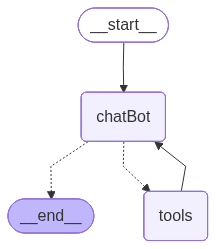

In [3]:

@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]

tavily_tool = TavilySearch(max_result = 2)
tools = [tavily_tool, human_assistance]

llm_with_tools = llm.bind_tools(tools)
memory = MemorySaver()

def chatBot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    return {"messages": [message]}

graph_builder = StateGraph(State)
graph_builder.add_node("chatBot", chatBot)
graph_builder.add_node("tools", ToolNode(tools))

graph_builder.add_edge(START, "chatBot")
graph_builder.add_conditional_edges(
    "chatBot",
    tools_condition,

)
graph_builder.add_edge("tools", "chatBot")

graph = graph_builder.compile(checkpointer=memory)

try: 
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)
    pass

In [4]:
user_input = "I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

In [5]:
events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (r3t4rjkgz)
 Call ID: r3t4rjkgz
  Args:
    query: I need expert guidance and assistance for building an AI agent.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (r3t4rjkgz)
 Call ID: r3t4rjkgz
  Args:
    query: I need expert guidance and assistance for building an AI agent.


In [6]:
# Run this right before your Command cell to debug
state = graph.get_state(config)
print(state.next)
print(state.tasks)


('tools',)
(PregelTask(id='e3ef07d6-34c5-8c81-cd36-ff9b350e8cf0', name='tools', path=('__pregel_pull', 'tools'), error=None, interrupts=(Interrupt(value={'query': 'I need expert guidance and assistance for building an AI agent.'}, id='d3a2824de5cc32c37ead891bde6562df'),), state=None, result=None),)


In [7]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command  = Command(resume={"data": human_response})

events = graph.stream(human_command, config=config, stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (r3t4rjkgz)
 Call ID: r3t4rjkgz
  Args:
    query: I need expert guidance and assistance for building an AI agent.
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (6ag8hxq03)
 Call ID: 6ag8hxq03
  Args:
    query: I need expert guidance and assistance for building an AI agent using LangGraph.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (6ag8hxq03)
 Call ID: 6ag8hxq03
  Args:
    query: I need expert guidance and assistance for building an AI agent using LangGraph.
